# Разведочный анализ данных Wine Dataset

**Тема:** построение основных графиков разведочного анализа данных (EDA).  
**Набор данных:** `load_wine` из библиотеки `sklearn.datasets`.  

Датасет Wine — это классический набор данных для задачи многоклассовой классификации. В нём 178 объектов, 13 числовых признаков и 3 класса вина.

В работе также искусственно добавлены пропуски, так как по условию, если пропусков нет, их можно создать самостоятельно. Затем строки с пропусками удаляются.


## 1. Импорт библиотек

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

## 2. Загрузка набора данных

In [18]:
wine = load_wine()

df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

print('Размер датасета:', df.shape)
df.head()

Размер датасета: (178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## 3. Общая информация о данных

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [20]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


## 4. Проверка пропусков

Изначально в датасете Wine пропуски отсутствуют, поэтому добавим их искусственно в несколько признаков.

In [21]:
df.isnull().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

## 5. Искусственное добавление пропусков

In [22]:
np.random.seed(42)

# Добавляем пропуски примерно в 5% строк для двух признаков
missing_alcohol = np.random.choice(df.index, size=int(len(df) * 0.05), replace=False)
missing_magnesium = np.random.choice(df.index, size=int(len(df) * 0.05), replace=False)

df.loc[missing_alcohol, 'alcohol'] = np.nan
df.loc[missing_magnesium, 'magnesium'] = np.nan

print('Количество пропусков после искусственного добавления:')
df.isnull().sum()

Количество пропусков после искусственного добавления:


alcohol                         8
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       8
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

## 6. Удаление строк с пропусками

По условию задания при наличии пропусков строки или колонки с пропусками необходимо удалить. В данной работе удаляются строки, содержащие пропуски.

In [23]:
df_clean = df.dropna()

print('Размер данных до удаления пропусков:', df.shape)
print('Размер данных после удаления пропусков:', df_clean.shape)
print('Оставшиеся пропуски:')
print(df_clean.isnull().sum().sum())

Размер данных до удаления пропусков: (178, 14)
Размер данных после удаления пропусков: (162, 14)
Оставшиеся пропуски:
0


## 7. Распределение классов target

График показывает, сколько объектов относится к каждому классу вина.

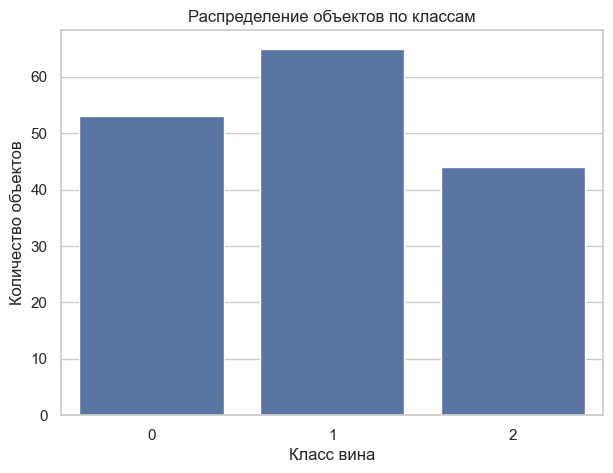

In [24]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df_clean, x='target')
plt.title('Распределение объектов по классам')
plt.xlabel('Класс вина')
plt.ylabel('Количество объектов')
plt.show()

## 8. Гистограммы признаков

Гистограммы используются для анализа распределения числовых признаков: можно увидеть, какие признаки распределены равномерно, какие имеют асимметрию, а где встречаются редкие значения.

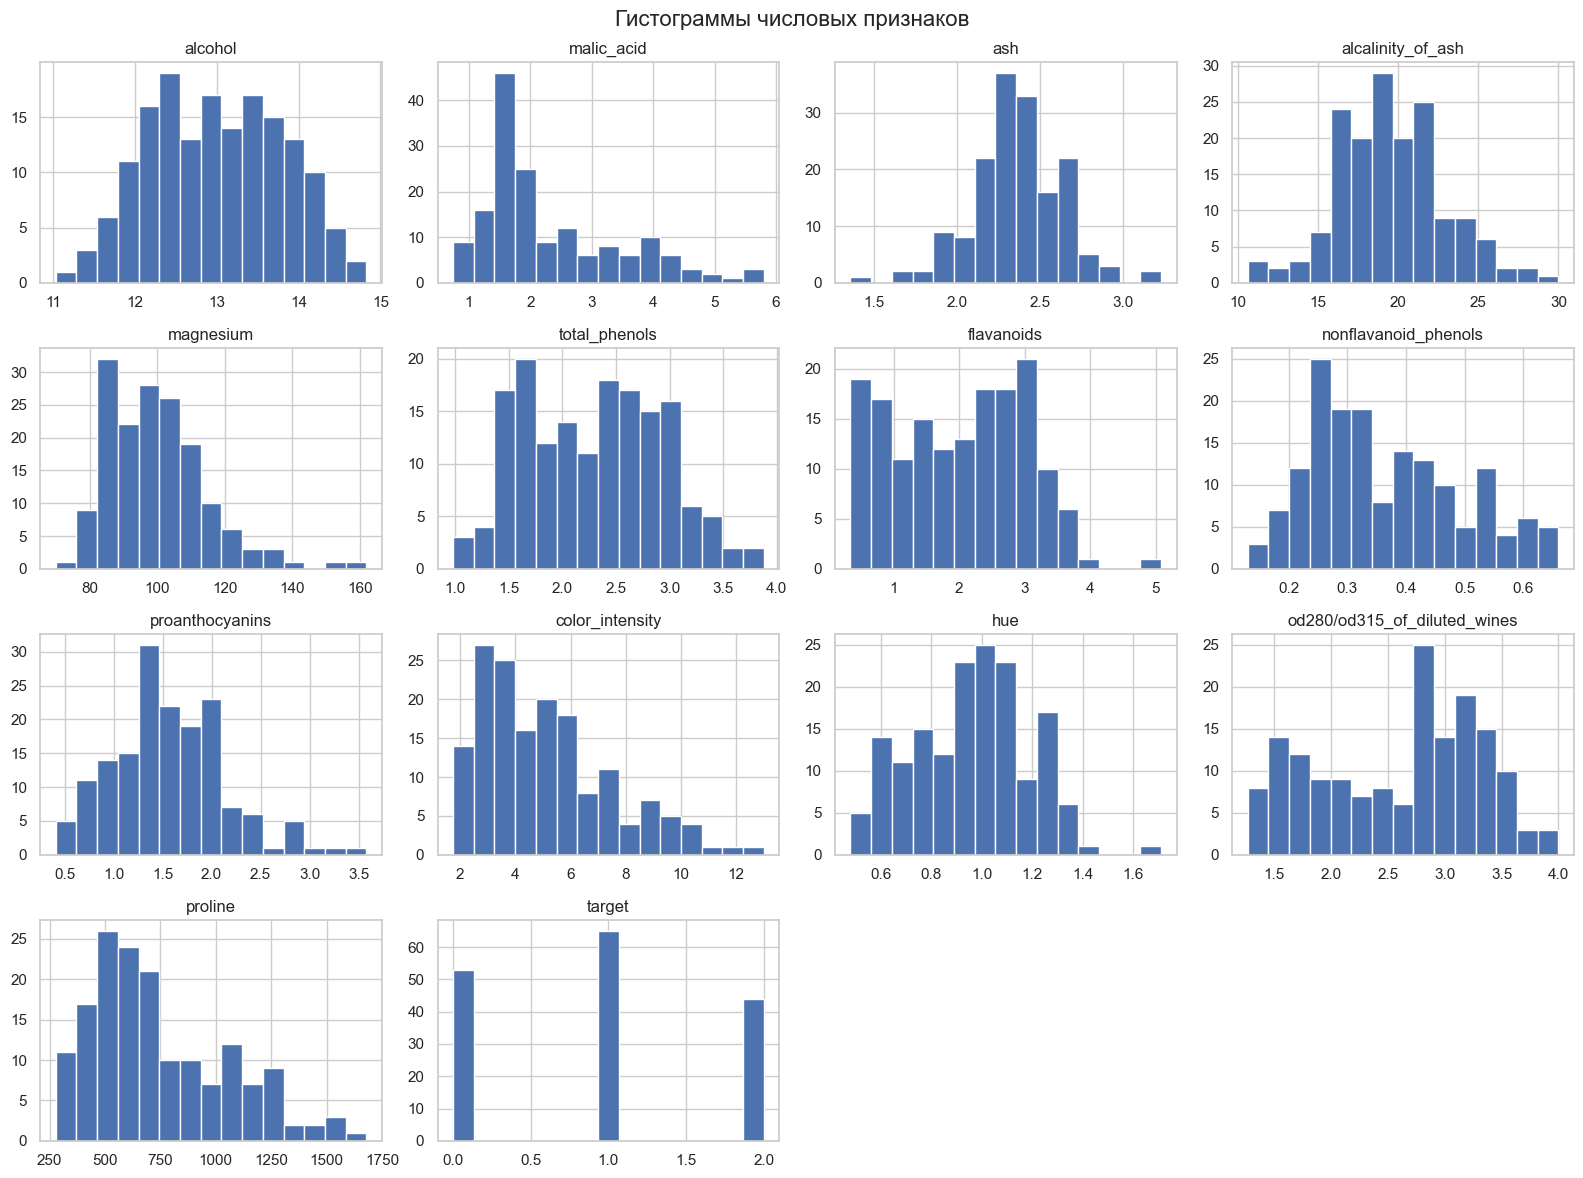

In [25]:
df_clean.hist(figsize=(16, 12), bins=15)
plt.suptitle('Гистограммы числовых признаков', fontsize=16)
plt.tight_layout()
plt.show()

## 9. Boxplot — «ящик с усами»

Для студентов групп ИУ5-63Б, ИУ5Ц-83Б нужно построить boxplot для произвольной колонки. Построим график для признака `alcohol`.

Boxplot позволяет увидеть медиану, межквартильный размах и возможные выбросы.

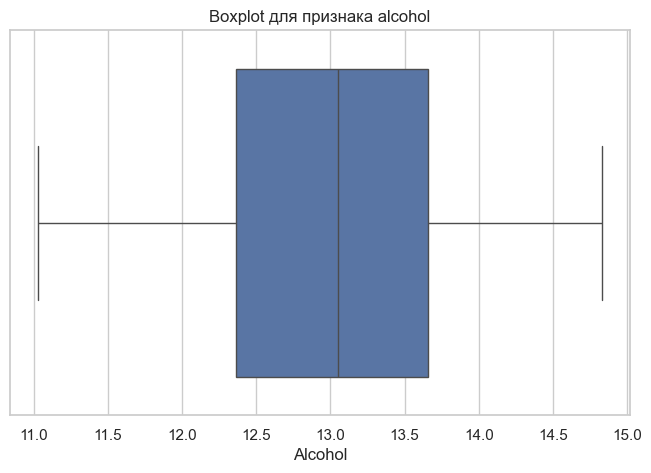

In [26]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_clean['alcohol'])
plt.title('Boxplot для признака alcohol')
plt.xlabel('Alcohol')
plt.show()

## 10. Boxplot признака alcohol по классам

Этот график показывает, отличается ли содержание алкоголя у разных классов вина.

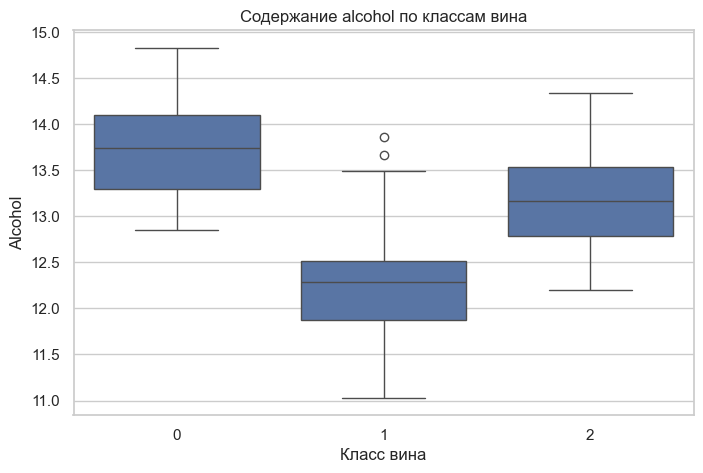

In [27]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='target', y='alcohol')
plt.title('Содержание alcohol по классам вина')
plt.xlabel('Класс вина')
plt.ylabel('Alcohol')
plt.show()

## 11. Корреляционная матрица

Корреляционная матрица показывает взаимосвязи между числовыми признаками. Чем ближе значение корреляции к 1 или -1, тем сильнее связь.

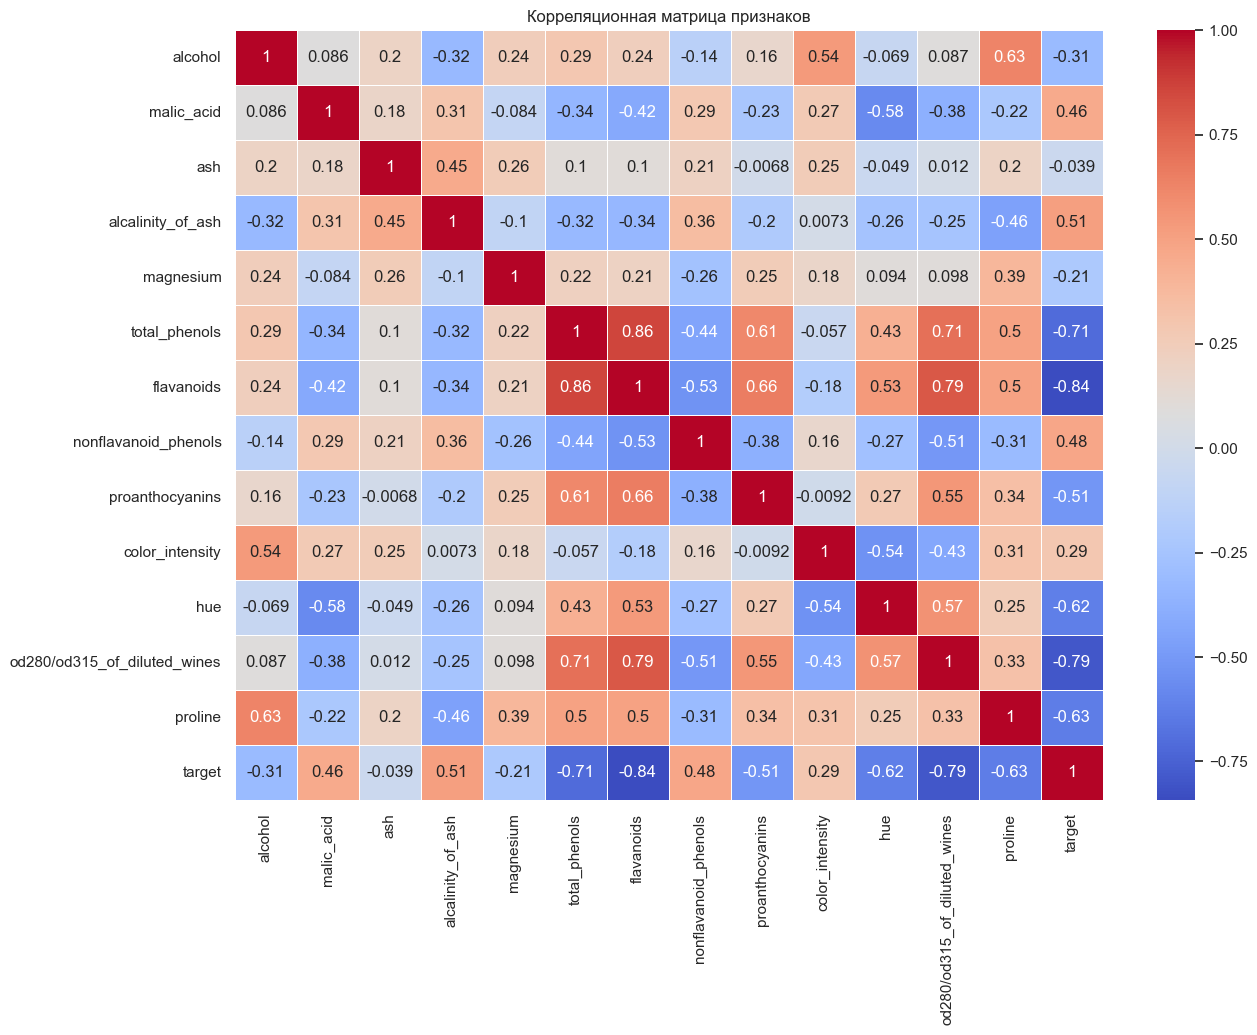

In [28]:
plt.figure(figsize=(14, 10))
corr = df_clean.corr()
sns.heatmap(corr, cmap='coolwarm', annot=True, linewidths=0.5)
plt.title('Корреляционная матрица признаков')
plt.show()

## 12. Топ корреляций между признаками

In [29]:
corr_pairs = corr.abs().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1]
corr_pairs.head(10)

flavanoids                    total_phenols                   0.858081
total_phenols                 flavanoids                      0.858081
target                        flavanoids                      0.842951
flavanoids                    target                          0.842951
od280/od315_of_diluted_wines  target                          0.793855
target                        od280/od315_of_diluted_wines    0.793855
flavanoids                    od280/od315_of_diluted_wines    0.792791
od280/od315_of_diluted_wines  flavanoids                      0.792791
total_phenols                 target                          0.711533
target                        total_phenols                   0.711533
dtype: float64

## 13. Диаграмма рассеяния

Scatter plot помогает увидеть связь между двумя признаками. Для анализа выбраны `alcohol` и `color_intensity`, так как они часто хорошо разделяют классы вина.

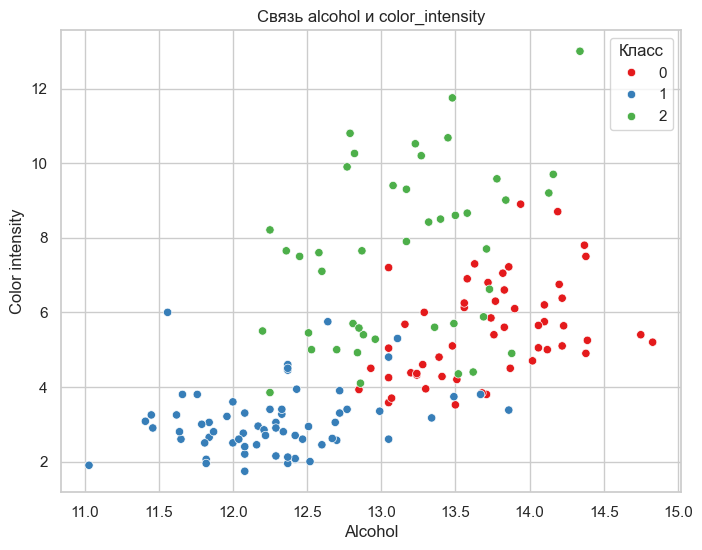

In [30]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_clean, x='alcohol', y='color_intensity', hue='target', palette='Set1')
plt.title('Связь alcohol и color_intensity')
plt.xlabel('Alcohol')
plt.ylabel('Color intensity')
plt.legend(title='Класс')
plt.show()

## 14. Pairplot для нескольких признаков

Pairplot строит попарные графики между выбранными признаками. Он помогает увидеть, насколько хорошо классы разделяются визуально.

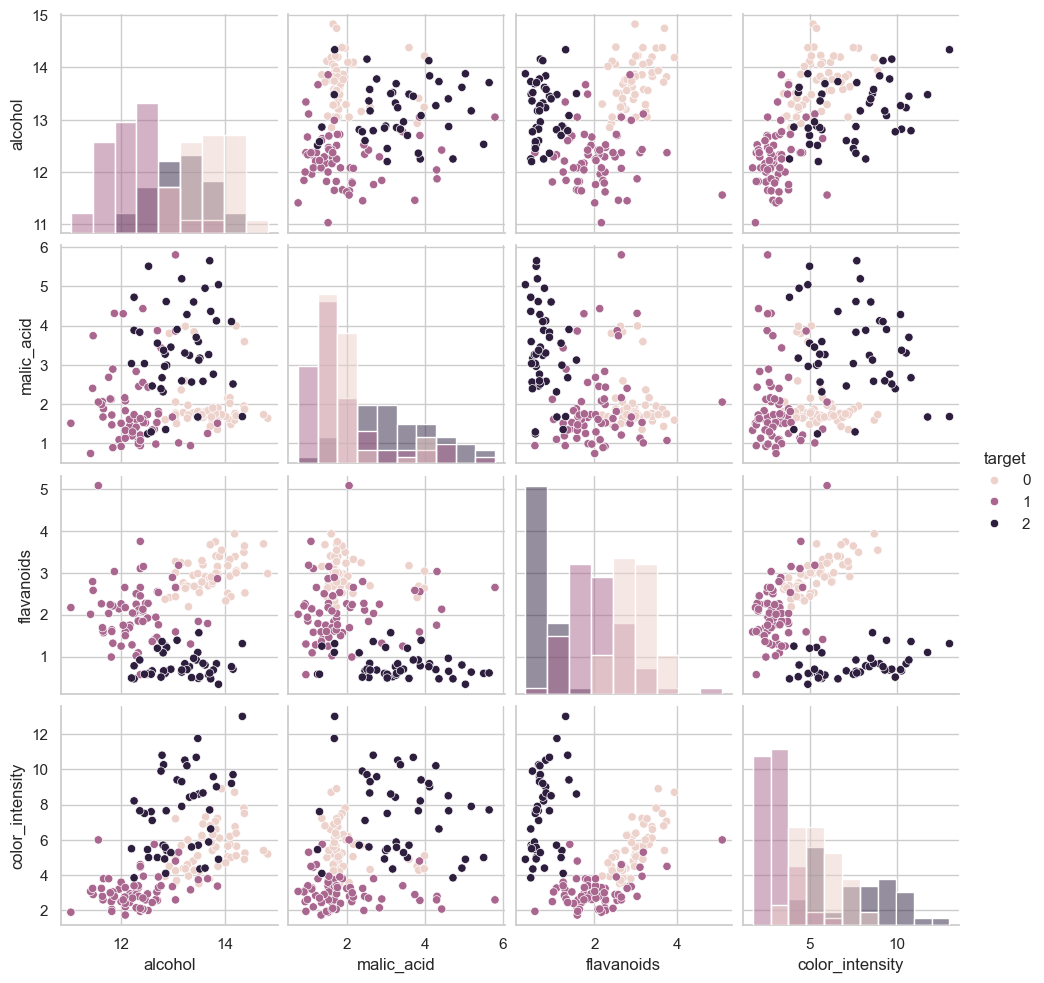

In [31]:
selected_columns = ['alcohol', 'malic_acid', 'flavanoids', 'color_intensity', 'target']
sns.pairplot(df_clean[selected_columns], hue='target', diag_kind='hist')
plt.show()

## 15. Выводы по построенным графикам

В ходе разведочного анализа данных были построены следующие графики:

1. **Countplot распределения классов** — показал количество объектов в каждом классе вина.
2. **Гистограммы признаков** — позволили оценить распределение числовых признаков.
3. **Boxplot для признака alcohol** — помог выявить медиану, разброс и возможные выбросы.
4. **Boxplot alcohol по классам** — показал различия содержания алкоголя между классами.
5. **Корреляционная матрица** — позволила найти признаки, между которыми есть сильные взаимосвязи.
6. **Scatter plot** — показал связь между признаками `alcohol` и `color_intensity`.
7. **Pairplot** — позволил визуально оценить разделимость классов по нескольким признакам.

### Основные выводы

- Изначально пропусков в данных нет, поэтому они были добавлены искусственно по условию задания.
- После удаления строк с пропусками размер набора данных уменьшился.
- Классы вина частично различаются по признакам `alcohol`, `color_intensity`, `flavanoids` и другим характеристикам.
- По графикам видно, что некоторые признаки могут быть полезны для классификации вина.
- В данных присутствуют признаки с разным масштабом значений, поэтому перед построением моделей машинного обучения может потребоваться масштабирование.
